## Fake Counterfactual C2 — Minimal Proof of Concept (Effusion)
- For each sample i, find the nearest training sample that C0 predicted differently (opposite predicted class). 
- Measure the distance between them in DISEASE-relevant attribute space (Call this: dist_cross)

### Hypothesis:
**Correct prediction**  

→ sample sits firmly in C0's predicted territory

→ the nearest opposite-predicted sample is FAR AWAY

→ dist_cross is LARGE

**Incorrect prediction**

→ sample is close to C0's decision boundary         

→ the nearest opposite-predicted sample is NEARBY       

→ dist_cross is SMALL

> If this hypothesis holds, dist_cross will separate correct from incorrect predictions, and **adding it to C2 will improve on the baseline AUC of 0.560.**


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import joblib


In [21]:
DISEASE = "Effusion"

disease_prob_col = f"{DISEASE.lower()}_prob"
disease_true_col = f"{DISEASE.lower()}_true"
disease_pred_col = f"{DISEASE.lower()}_pred"



In [22]:
if DISEASE == "Effusion":
    prefixes_of_interest = ["Left Lung", "Right Lung", "Mediastinum",
                        "Left Hilus Pulmonis", "Right Hilus Pulmonis"]
if DISEASE == "Cardiomegaly":
    prefixes_of_interest = ["Heart", "Aorta"]
    
if DISEASE == "Pneumothorax":
    prefixes_of_interest = ["Left Lung", "Right Lung", "Mediastinum",
                        "Left Hilus Pulmonis", "Right Hilus Pulmonis"]
    

In [23]:
BASE_DIR    = "/zhome/d0/a/221493/thesis"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
OUTPUT_DIR  = os.path.join(RESULTS_DIR, f"C2_sim_cf/{DISEASE.lower()}")
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [24]:
# Load C0 and C1 results

c0_train = pd.read_csv(os.path.join(RESULTS_DIR, f"C0_baseline/{DISEASE.lower()}/train_c0_{DISEASE.lower()}.csv"))
c0_valid = pd.read_csv(os.path.join(RESULTS_DIR, f"C0_baseline/{DISEASE.lower()}/valid_c0_{DISEASE.lower()}.csv"))
c1_train = pd.read_csv(os.path.join(RESULTS_DIR, "C1_attributes/train_c1_attribute_vector.csv"))
c1_valid = pd.read_csv(os.path.join(RESULTS_DIR, "C1_attributes/valid_c1_attribute_vector.csv"))

# Print the size of each dataframe and correctness distribution
print(f"C0 Train: {len(c0_train)} rows | C0 Valid: {len(c0_valid)} rows")
print(f"C1 Train: {len(c1_train)} rows | C1 Valid: {len(c1_valid)} rows")


# Merge C0 and C1 on 'path' to get a combined dataframe with all relevant columns
train_df = c0_train.merge(c1_train, on="path", how="inner")
valid_df = c0_valid.merge(c1_valid, on="path", how="inner")

# Rename prob/true/pred to be disease-specific
for df in [train_df, valid_df]:
    df.rename(columns={col: f"{DISEASE.lower()}_{col}"
                       for col in ["prob", "true", "pred"]
                       if col in df.columns}, inplace=True)

print(f"Train: {len(train_df)} rows | Valid: {len(valid_df)} rows")
print(f"Train correctness: {train_df['correct'].value_counts().to_dict()}")
print(f"Valid correctness: {valid_df['correct'].value_counts().to_dict()}")

C0 Train: 46548 rows | C0 Valid: 200 rows
C1 Train: 64534 rows | C1 Valid: 200 rows
Train: 46548 rows | Valid: 200 rows
Train correctness: {1: 34737, 0: 11811}
Valid correctness: {1: 156, 0: 44}


In [25]:
train_df

,path,effusion_prob,effusion_true,effusion_pred,correct,margin,patient_id,age_pred,sex_male,sex_female,...,Right Hilus Pulmonis_area_pixels,Right Hilus Pulmonis_bbox_width,Right Hilus Pulmonis_bbox_height,Right Hilus Pulmonis_bbox_ratio,Right Hilus Pulmonis_perimeter,Aorta_area_pixels,Aorta_bbox_width,Aorta_bbox_height,Aorta_bbox_ratio,Aorta_perimeter
0,CheXpert-v1.0-small/train/patient00001/study1/...,0.641115,0.0,0,1,0.002689,patient00001,46.296631,7.792770e-07,9.999992e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CheXpert-v1.0-small/train/patient00002/study2/...,0.681220,1.0,1,1,0.037416,patient00002,63.702305,1.760454e-05,9.999824e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CheXpert-v1.0-small/train/patient00004/study1/...,0.570345,0.0,0,1,0.073459,patient00004,26.006752,3.213766e-03,9.967862e-01,...,3625.0,51.0,129.0,0.395349,310.208150,2958.0,38.0,97.0,3.917526e-01,235.681239
3,CheXpert-v1.0-small/train/patient00005/study1/...,0.579604,0.0,0,1,0.064200,patient00005,41.602314,9.999933e-01,6.703691e-06,...,2209.0,38.0,92.0,0.413043,223.681239,1585.0,40.0,57.0,7.017544e-01,159.438598
4,CheXpert-v1.0-small/train/patient00006/study1/...,0.556092,0.0,0,1,0.087712,patient00006,51.069099,3.701182e-01,6.298818e-01,...,6660.0,74.0,146.0,0.506849,399.462984,5355.0,71.0,96.0,7.395833e-01,286.208151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46543,CheXpert-v1.0-small/train/patient64532/study1/...,0.527807,0.0,0,1,0.115997,patient64532,50.757626,2.449746e-03,9.975503e-01,...,2256.0,49.0,66.0,0.742424,184.308656,3.0,2.0,0.0,2.000000e+06,4.000000
46544,CheXpert-v1.0-small/train/patient64534/study1/...,0.537119,1.0,0,0,0.106685,patient64534,64.415741,9.991718e-01,8.281596e-04,...,4682.0,69.0,132.0,0.522727,331.705624,3904.0,67.0,83.0,8.072289e-01,251.279218
46545,CheXpert-v1.0-small/train/patient64535/study1/...,0.673462,1.0,1,1,0.029658,patient64535,60.565922,1.000000e+00,8.610759e-09,...,6651.0,109.0,191.0,0.570681,551.487369,5883.0,57.0,142.0,4.014084e-01,390.391916
46546,CheXpert-v1.0-small/train/patient64539/study1/...,0.676210,1.0,1,1,0.032406,patient64539,13.358482,7.092757e-01,2.907243e-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
valid_df

,path,effusion_prob,effusion_true,effusion_pred,correct,margin,patient_id,age_pred,sex_male,sex_female,...,Weasand_area_pixels,Weasand_bbox_width,Weasand_bbox_height,Weasand_bbox_ratio,Weasand_perimeter,Spine_area_pixels,Spine_bbox_width,Spine_bbox_height,Spine_bbox_ratio,Spine_perimeter
0,CheXpert-v1.0-small/valid/patient64541/study1/...,0.615238,1.0,0,0,0.028566,patient64541,66.749069,9.999987e-01,1.315601e-06,...,8965.0,98.0,246.0,0.398374,686.416301,27671.0,92.0,483.0,0.190476,1070.717816
1,CheXpert-v1.0-small/valid/patient64542/study1/...,0.509363,0.0,0,1,0.134441,patient64542,62.223160,1.000000e+00,9.311161e-09,...,6755.0,93.0,208.0,0.447115,584.960457,23698.0,65.0,455.0,0.142857,1013.421354
2,CheXpert-v1.0-small/valid/patient64543/study1/...,0.657029,1.0,1,1,0.013225,patient64543,75.284607,4.660334e-02,9.533966e-01,...,3897.0,31.0,163.0,0.190184,363.681239,14551.0,49.0,399.0,0.122807,875.847760
3,CheXpert-v1.0-small/valid/patient64544/study1/...,0.506830,0.0,0,1,0.136974,patient64544,43.914021,1.934439e-06,9.999981e-01,...,7015.0,91.0,224.0,0.406250,630.173660,22443.0,62.0,477.0,0.129979,1058.835567
4,CheXpert-v1.0-small/valid/patient64545/study1/...,0.681022,1.0,1,1,0.037218,patient64545,64.229874,2.646871e-06,9.999974e-01,...,6664.0,92.0,195.0,0.471795,570.658942,20929.0,61.0,453.0,0.134658,1029.989895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,CheXpert-v1.0-small/valid/patient64736/study1/...,0.682796,0.0,1,0,0.038992,patient64736,61.820938,1.385039e-09,1.000000e+00,...,8402.0,95.0,243.0,0.390947,685.972650,17587.0,72.0,484.0,0.148760,301.480229
196,CheXpert-v1.0-small/valid/patient64737/study1/...,0.625245,0.0,0,1,0.018559,patient64737,60.223877,9.999998e-01,2.539865e-07,...,6018.0,55.0,238.0,0.231092,553.220343,24800.0,73.0,477.0,0.153040,1072.333041
197,CheXpert-v1.0-small/valid/patient64738/study1/...,0.579751,1.0,0,0,0.064053,patient64738,63.951572,9.800821e-01,1.991785e-02,...,6453.0,125.0,234.0,0.534188,96.669046,28657.0,114.0,442.0,0.257919,1021.144222
198,CheXpert-v1.0-small/valid/patient64739/study1/...,0.533991,0.0,0,1,0.109813,patient64739,49.761253,1.098210e-04,9.998902e-01,...,8804.0,111.0,238.0,0.466387,699.470123,27695.0,83.0,449.0,0.184855,1033.161468


In [27]:
all_cols = [c for c in c1_train.columns if c not in ["path", "patient_id"]]

attribute_cols = [c for c in all_cols
                  if any(c.lower().startswith(p.lower()) for p in prefixes_of_interest)]

print(f"Effusion-relevant attributes ({len(attribute_cols)}):")
print(attribute_cols)

# overwrite and use all attributes actually 
attribute_cols = all_cols
print(f"\nUsing all attributes ({len(attribute_cols)}):")
print(attribute_cols)

# Drop rows missing any of these attributes
train_clean = train_df.dropna(subset=attribute_cols).copy()
valid_clean = valid_df.dropna(subset=attribute_cols).copy()
print(f"\nAfter dropping NaN — train: {len(train_clean)} | valid: {len(valid_clean)}")

Effusion-relevant attributes (25):
['Left Lung_area_pixels', 'Left Lung_bbox_width', 'Left Lung_bbox_height', 'Left Lung_bbox_ratio', 'Left Lung_perimeter', 'Right Lung_area_pixels', 'Right Lung_bbox_width', 'Right Lung_bbox_height', 'Right Lung_bbox_ratio', 'Right Lung_perimeter', 'Left Hilus Pulmonis_area_pixels', 'Left Hilus Pulmonis_bbox_width', 'Left Hilus Pulmonis_bbox_height', 'Left Hilus Pulmonis_bbox_ratio', 'Left Hilus Pulmonis_perimeter', 'Mediastinum_area_pixels', 'Mediastinum_bbox_width', 'Mediastinum_bbox_height', 'Mediastinum_bbox_ratio', 'Mediastinum_perimeter', 'Right Hilus Pulmonis_area_pixels', 'Right Hilus Pulmonis_bbox_width', 'Right Hilus Pulmonis_bbox_height', 'Right Hilus Pulmonis_bbox_ratio', 'Right Hilus Pulmonis_perimeter']

Using all attributes (76):
['age_pred', 'sex_male', 'sex_female', 'race_white', 'race_black', 'race_asian', 'Left Clavicle_area_pixels', 'Left Clavicle_bbox_width', 'Left Clavicle_bbox_height', 'Left Clavicle_bbox_ratio', 'Left Clavicle_p

In [28]:
### Find the nearest opposite-predicted neighbor for every sample

# We split the training set into two groups based on what C0 predicted:
#   - pred_1_samples: samples C0 predicted as Effusion-positive
#   - pred_0_samples: samples C0 predicted as Effusion-negative
#
# For each sample i:
#   - If C0 predicted i as positive → look for its nearest neighbor among pred_0_samples
#   - If C0 predicted i as negative → look for its nearest neighbor among pred_1_samples
#   - Measure the Euclidean distance between them in attribute space → dist_cross

In [29]:
# Split training set by C0's predicted label
pred_1_train = train_clean[train_clean[disease_pred_col] == 1][attribute_cols].values.astype(float)
pred_0_train = train_clean[train_clean[disease_pred_col] == 0][attribute_cols].values.astype(float)

print(f"Pred-positive samples in train: {len(pred_1_train)}")
print(f"Pred-negative samples in train: {len(pred_0_train)}")

# Build one neighbor index per predicted class
nn_pred_1 = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(pred_1_train)
nn_pred_0 = NearestNeighbors(n_neighbors=1, metric="euclidean").fit(pred_0_train)

Pred-positive samples in train: 18861
Pred-negative samples in train: 16776


In [30]:
def get_dist_cross(query_df, attribute_cols, disease_pred_col,
                   nn_pred_1, nn_pred_0):
    """
    For each sample in query_df, find the distance to the nearest
    training sample that C0 predicted oppositely.

    Returns a Series of dist_cross values (one per sample).
    """
    dist_cross = []

    for _, row in query_df.iterrows():
        A_i    = row[attribute_cols].values.astype(float).reshape(1, -1)
        y_pred = int(row[disease_pred_col])

        # Look in the OPPOSITE predicted class index
        if y_pred == 1:
            dist, _ = nn_pred_0.kneighbors(A_i)
        else:
            dist, _ = nn_pred_1.kneighbors(A_i)

        dist_cross.append(dist[0][0])

    return np.array(dist_cross)


In [31]:
print("Computing dist_cross for train...")
train_dist_cross = get_dist_cross(train_clean, attribute_cols, disease_pred_col,
                                   nn_pred_1, nn_pred_0)

print("Computing dist_cross for valid...")
valid_dist_cross = get_dist_cross(valid_clean, attribute_cols, disease_pred_col,
                                   nn_pred_1, nn_pred_0)

train_clean = train_clean.copy()
valid_clean = valid_clean.copy()
train_clean["dist_cross"] = train_dist_cross
valid_clean["dist_cross"] = valid_dist_cross

print("Done.")
print(f"\nTrain dist_cross — mean: {train_dist_cross.mean():.2f}, std: {train_dist_cross.std():.2f}")
print(f"Valid dist_cross — mean: {valid_dist_cross.mean():.2f}, std: {valid_dist_cross.std():.2f}")

Computing dist_cross for train...
Computing dist_cross for valid...
Done.

Train dist_cross — mean: 7699.06, std: 175869.55
Valid dist_cross — mean: 5936.82, std: 1967.00


In [32]:
### Sanity check — is dist_cross actually different for correct vs. incorrect?

# This is the only thing that matters right now.
# If the distributions overlap completely → the hypothesis doesn't hold for Effusion.
# If correct predictions show larger dist_cross → the hypothesis holds → proceed to C2.

In [33]:
correct_mask   = train_clean["correct"] == 1
incorrect_mask = ~correct_mask

mean_correct   = train_clean["dist_cross"][correct_mask].mean()
mean_incorrect = train_clean["dist_cross"][incorrect_mask].mean()
print(f"Mean dist_cross — Correct: {mean_correct:.2f} | Incorrect: {mean_incorrect:.2f}")
print(f"Difference: {mean_correct - mean_incorrect:+.2f}")


Mean dist_cross — Correct: 8385.41 | Incorrect: 5798.19
Difference: +2587.22


In [34]:
### Train C2
#
# Compare two models:
#   1. Baseline:  [prob]          
#   2. + dist_cross: [dist_cross] — does adding our one fake CF feature help?

In [35]:
# Define X and y for both train and valid sets
y_train = train_clean["correct"].values
y_valid = valid_clean["correct"].values


# For the first model, BASELINE, we only use the original C0 probability as input.
X_train_base = train_clean[[disease_prob_col]].values
X_valid_base = valid_clean[[disease_prob_col]].values

# For the second model, AUGMENTED, we use dist_cross as the only input.
X_train_aug  = train_clean[["dist_cross"]].values
X_valid_aug  = valid_clean[["dist_cross"]].values

# For a third mode, MIXED, we will combine both features
X_train_mixed = train_clean[[disease_prob_col, "dist_cross"]].values
X_valid_mixed = valid_clean[[disease_prob_col, "dist_cross"]].values

sc_base = StandardScaler()
sc_aug  = StandardScaler()
sc_mixed = StandardScaler()

X_train_base_sc = sc_base.fit_transform(X_train_base)
X_valid_base_sc = sc_base.transform(X_valid_base)
X_train_aug_sc  = sc_aug.fit_transform(X_train_aug)
X_valid_aug_sc  = sc_aug.transform(X_valid_aug)
X_train_mixed_sc = sc_mixed.fit_transform(X_train_mixed)
X_valid_mixed_sc = sc_mixed.transform(X_valid_mixed)

c2_base = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
c2_aug  = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
c2_mixed = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
c2_base.fit(X_train_base_sc, y_train)
c2_aug.fit(X_train_aug_sc,   y_train)
c2_mixed.fit(X_train_mixed_sc, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


  Baseline — prob only  |  AUC = 0.5274
              precision    recall  f1-score   support

   Incorrect       0.20      0.31      0.24        35
     Correct       0.73      0.59      0.66       111

    accuracy                           0.53       146
   macro avg       0.46      0.45      0.45       146
weighted avg       0.60      0.53      0.56       146


  Dist_cross ('fake-cf')  |  AUC = 0.5781
              precision    recall  f1-score   support

   Incorrect       0.30      0.74      0.42        35
     Correct       0.84      0.44      0.58       111

    accuracy                           0.51       146
   macro avg       0.57      0.59      0.50       146
weighted avg       0.71      0.51      0.54       146


  Mixed (prob + dist_cross)  |  AUC = 0.5274
              precision    recall  f1-score   support

   Incorrect       0.20      0.31      0.24        35
     Correct       0.73      0.59      0.66       111

    accuracy                           0.53       14

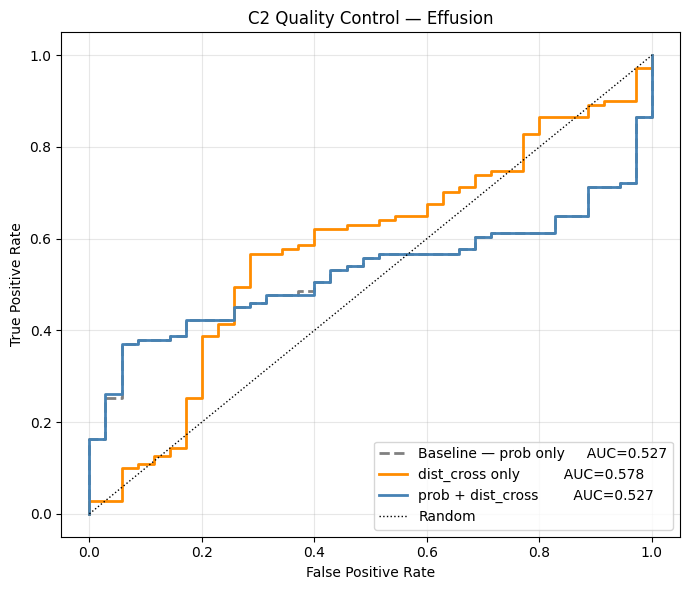


Baseline AUC (prob only)   : 0.5274
Fake CF AUC (dist_cross)   : 0.5781
Combined AUC (prob + dist) : 0.5274

Saved to: /zhome/d0/a/221493/thesis/results/C2_sim_cf/effusion


In [36]:

# Define a function to evaluate a model and print its classification report and AUC
def evaluate(model, X_sc, y_true, label):
    y_prob = model.predict_proba(X_sc)[:, 1]
    y_pred_labels = model.predict(X_sc)
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    print(f"\n{'='*50}")
    print(f"  {label}  |  AUC = {auc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred_labels,
                                 target_names=["Incorrect", "Correct"]))
    return auc, fpr, tpr

# Run the evaluations and plot the ROC curves
auc_base, fpr_base, tpr_base = evaluate(c2_base, X_valid_base_sc, y_valid,
                                         "Baseline — prob only")
auc_aug,  fpr_aug,  tpr_aug  = evaluate(c2_aug,  X_valid_aug_sc,  y_valid,
                                         "Dist_cross ('fake-cf')")
auc_mixed, fpr_mixed, tpr_mixed = evaluate(c2_mixed, X_valid_mixed_sc, y_valid,
                                         "Mixed (prob + dist_cross)")

# %% plots stuff
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_base, tpr_base, color="gray",       lw=2, ls="--", label=f"Baseline — prob only     AUC={auc_base:.3f}")
ax.plot(fpr_aug,   tpr_aug,   color="darkorange", lw=2,          label=f"dist_cross only          AUC={auc_aug:.3f}")
ax.plot(fpr_mixed, tpr_mixed, color="steelblue",  lw=2,          label=f"prob + dist_cross        AUC={auc_mixed:.3f}")
ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"C2 Quality Control — {DISEASE}")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_comparison.png"), dpi=150)
plt.show()
print(f"\nBaseline AUC (prob only)   : {auc_base:.4f}")
print(f"Fake CF AUC (dist_cross)   : {auc_aug:.4f}")
print(f"Combined AUC (prob + dist) : {auc_mixed:.4f}")


# Save outputs
joblib.dump(c2_base, os.path.join(OUTPUT_DIR, "c2_baseline.pkl"))
joblib.dump(c2_aug,  os.path.join(OUTPUT_DIR, "c2_dist_cross.pkl"))
train_clean.to_csv(os.path.join(OUTPUT_DIR, "train_with_dist_cross.csv"), index=False)
valid_clean.to_csv(os.path.join(OUTPUT_DIR, "valid_with_dist_cross.csv"), index=False)
print(f"\nSaved to: {OUTPUT_DIR}")